# HNSW Project — Week 2: Bayesian Optimization of Global Construction Parameters

**CS328 Project | IIT Gandhinagar | 2026**

This notebook covers Week 2 of the project timeline:
1. Reload the dataset and recreate the exact Week 1 train/test splits
2. Rebuild the vanilla HNSW baseline (M=16, ef_con=200) for reference
3. Define the Bayesian optimization objective with a latency-aware score
4. Run Bayesian optimization (via Optuna) over M, ef_con, mL
5. Run Grid Search over the same parameter space
6. Run Random Search over the same parameter space
7. Evaluate all four methods on the held-out test set (full Recall-QPS frontier)
8. Plot all frontiers on a single comparison chart (overlaid on the Week 1 baseline)
9. Summary table

**Proposal alignment (Section 3.1):**
> *"We treat the mapping from parameter values to final recall and QPS as a black-box
> function and apply Bayesian optimization (via optuna) to find the configuration that
> maximizes recall subject to a latency budget, using training query examples and their
> ground-truth outputs as the evaluation signal. We compare the learned configuration
> against vanilla HNSW with defaults, grid search over the same space, and random search
> to isolate the specific benefit of Bayesian optimization as the learning mechanism."*

---

## Section 1 — Install and Import Libraries

In [1]:
!pip install hnswlib optuna xgboost h5py --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import time
import h5py
import os
import itertools
import matplotlib.pyplot as plt
import hnswlib
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from importlib.metadata import version

# Suppress Optuna's per-trial INFO logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"numpy   : {np.__version__}")
print(f"hnswlib : {version('hnswlib')}")
print(f"optuna  : {optuna.__version__}")
print(f"h5py    : {version('h5py')}")
print()
print("All libraries imported successfully!")

numpy   : 2.0.2
hnswlib : 0.8.0
optuna  : 4.8.0
h5py    : 3.16.0

All libraries imported successfully!


## Section 2 — Constants (must match Week 1 exactly)

These values are fixed for the entire project. Changing them would break
comparability with the Week 1 baseline.

In [3]:
# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_URL  = 'http://ann-benchmarks.com/fashion-mnist-784-euclidean.hdf5'
DATASET_FILE = 'fashion-mnist-784-euclidean.hdf5'

if os.path.exists(DATASET_FILE):
    print(f"Dataset already present: {DATASET_FILE}")
else:
    print("Downloading Fashion-MNIST from ann-benchmarks (~200 MB)...")
    t0 = time.time()
    !wget -q --show-progress -O {DATASET_FILE} {DATASET_URL}
    print(f"Done in {time.time() - t0:.1f}s")

with h5py.File(DATASET_FILE, 'r') as f:
    base_vectors = f['train'][:].astype(np.float32)

print(f"Base vectors loaded : {base_vectors.shape}")

# ── Evaluation ───────────────────────────────────────────────────────────────
K              = 10           # Recall@10 throughout
EF_SEARCH_VALS = [10, 20, 30, 50, 80, 100, 150, 200, 300, 500]  # frontier sweep
RANDOM_SEED    = 42
SPACE          = 'l2'

# ── Week 1 vanilla baseline (DO NOT CHANGE) ──────────────────────────────────
M_DEFAULT    = 16
EF_CON_DEFAULT = 200

# ── Week 2 search space (Section 3.1 of proposal) ────────────────────────────
# M and ef_con: same grid used for all three search methods so comparisons are fair
M_VALUES      = [8, 16, 24, 32, 48]
EF_CON_VALUES = [100, 150, 200, 300, 400]

# ── Latency budget for the Bayesian objective ─────────────────────────────────
# Proposal: "maximizes recall subject to a latency budget"
# We enforce this as a soft penalty: if QPS < MIN_QPS, subtract a penalty.
# Evaluated at ef_search = EF_SEARCH_EVAL (a representative operating point).
EF_SEARCH_EVAL = 50            # single ef used during optimization
MIN_QPS        = 2000.0        # target minimum QPS
LATENCY_LAMBDA = 0.5           # penalty weight per 1000-QPS shortfall

# ── Optuna trials ─────────────────────────────────────────────────────────────
N_BAYES_TRIALS  = 50
N_RANDOM_TRIALS = 50

print("Constants defined.")
print(f"  Vanilla baseline : M={M_DEFAULT}, ef_con={EF_CON_DEFAULT}")
print(f"  Search space     : M in {M_VALUES}")
print(f"                     ef_con in {EF_CON_VALUES}")
print(f"  Grid configs     : {len(M_VALUES) * len(EF_CON_VALUES)} (mL fixed at default for grid)")
print(f"  Bayesian trials  : {N_BAYES_TRIALS}")
print(f"  Random trials    : {N_RANDOM_TRIALS}")

fashion-mnist-784-e 100%[===================>] 216.99M  71.6MB/s    in 3.0s    
Done in 3.2s
Base vectors loaded : (60000, 784)
Constants defined.
  Vanilla baseline : M=16, ef_con=200
  Search space     : M in [8, 16, 24, 32, 48]
                     ef_con in [100, 150, 200, 300, 400]
  Grid configs     : 25 (mL fixed at default for grid)
  Bayesian trials  : 50
  Random trials    : 50


## Loading Week 1 Outputs


In [7]:
# Load Week 1 saved outputs — no recomputation needed
train_queries        = np.load('train_queries.npy')
test_queries         = np.load('test_queries.npy')
train_gt             = np.load('train_gt.npy')
test_gt              = np.load('test_gt.npy')
vanilla_test_results = np.load('vanilla_results.npy', allow_pickle=True).tolist()

print(f"Train queries : {train_queries.shape}")
print(f"Test queries  : {test_queries.shape}")
print(f"Train GT      : {train_gt.shape}")
print(f"Test GT       : {test_gt.shape}")
print(f"Vanilla results loaded : {len(vanilla_test_results)} ef_search points")

Train queries : (8000, 784)
Test queries  : (2000, 784)
Train GT      : (8000, 10)
Test GT       : (2000, 10)
Vanilla results loaded : 10 ef_search points


## Section 4 — Shared Utilities

These functions are identical in interface to Week 1 so results can be
directly compared and the same `plot_recall_qps` function works for both weeks.

In [8]:
def build_hnsw_index(base_vectors, M, ef_construction, space='l2', seed=42):
    dim = base_vectors.shape[1]
    N   = base_vectors.shape[0]
    index = hnswlib.Index(space=space, dim=dim)
    index.init_index(max_elements=N, ef_construction=ef_construction,
                     M=M, random_seed=seed)
    t0 = time.time()
    index.add_items(base_vectors, np.arange(N))
    build_time = time.time() - t0
    return index, build_time


def evaluate_index(index, query_vectors, ground_truth, ef_search_values, k=10):
    results = []
    Q = query_vectors.shape[0]
    for ef in ef_search_values:
        index.set_ef(ef)
        t0 = time.time()
        labels, _ = index.knn_query(query_vectors, k=k)
        elapsed = time.time() - t0
        qps = Q / elapsed
        recall = np.mean([
            len(set(labels[i]) & set(ground_truth[i])) / k
            for i in range(Q)
        ])
        results.append({'ef_search': ef, 'recall': recall, 'qps': qps})
    return results


def plot_recall_qps(results_list, labels,
                    title='Recall@10 vs QPS Frontier',
                    filename='recall_qps.png'):
    colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    markers = ['o', 's', '^', 'D']
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (results, label) in enumerate(zip(results_list, labels)):
        recalls = [r['recall']    for r in results]
        qps     = [r['qps']       for r in results]
        efs     = [r['ef_search'] for r in results]
        color   = colors[i % len(colors)]
        marker  = markers[i % len(markers)]
        ax.plot(qps, recalls, marker=marker, color=color, label=label,
                linewidth=2, markersize=6, zorder=3)
        for qp, rc, ef in zip(qps, recalls, efs):
            if ef in [10, 50, 200, 500]:
                ax.annotate(f'ef={ef}', (qp, rc),
                            textcoords='offset points', xytext=(6, 4),
                            fontsize=8, color=color, alpha=0.85)
    ax.set_xlabel('QPS (Queries Per Second)', fontsize=12)
    ax.set_ylabel('Recall@10', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(fontsize=10, loc='lower right')
    ax.text(0.98, 0.05, 'upper-right = better',
            transform=ax.transAxes, fontsize=8, color='gray',
            ha='right', style='italic')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {filename}")

print("Utilities defined.")

Utilities defined.


## Section 6 — Load Vanilla Baseline (from Week 1)

In [9]:
print("Vanilla baseline loaded from Week 1 outputs.")
print(f"\n{'ef_search':>10} | {'Recall@10':>10} | {'QPS':>10}")
print("-" * 36)
for r in vanilla_test_results:
    print(f"{r['ef_search']:>10} | {r['recall']:>10.4f} | {r['qps']:>10.1f}")

Vanilla baseline loaded from Week 1 outputs.

 ef_search |  Recall@10 |        QPS
------------------------------------
        10 |     0.9315 |    14072.6
        20 |     0.9785 |     6836.3
        30 |     0.9898 |     5166.7
        50 |     0.9958 |     4131.8
        80 |     0.9980 |     3618.6
       100 |     0.9983 |     2675.3
       150 |     0.9990 |     1608.2
       200 |     0.9990 |     1305.2
       300 |     0.9992 |     1318.3
       500 |     0.9998 |      940.3


## Section 7 — Bayesian Optimization

**Objective (aligned with Section 3.1 of the proposal):**  
Maximize recall subject to a latency budget.  
Score = Recall@10 − λ × max(0, (MIN_QPS − QPS) / 1000)

- Evaluated on **training queries** at a single representative `ef_search`
- Parameters searched: `M`, `ef_con`
- Optimizer: Optuna TPE sampler (Tree-structured Parzen Estimator)

In [10]:
def bayes_objective(trial):
    """
    Black-box objective for Bayesian optimization.
    Returns: recall − latency_penalty  (higher is better)
    """
    M       = trial.suggest_categorical('M', M_VALUES)
    ef_con  = trial.suggest_categorical('ef_construction', EF_CON_VALUES)

    index, _ = build_hnsw_index(base_vectors, M=M,
                                 ef_construction=ef_con)

    results = evaluate_index(index, train_queries, train_gt,
                             ef_search_values=[EF_SEARCH_EVAL], k=K)
    recall = results[0]['recall']
    qps    = results[0]['qps']

    # Latency penalty: subtract if we fall below the QPS budget
    latency_penalty = LATENCY_LAMBDA * max(0.0, (MIN_QPS - qps) / 1000.0)
    score = recall - latency_penalty

    # Store extra attributes so we can inspect them after the study
    trial.set_user_attr('recall', recall)
    trial.set_user_attr('qps', qps)

    return score


print(f"Running Bayesian optimization ({N_BAYES_TRIALS} trials)...")
print(f"  Objective  : recall - {LATENCY_LAMBDA} * max(0, ({MIN_QPS} - QPS) / 1000)")
print(f"  Evaluated at ef_search={EF_SEARCH_EVAL} on training queries")
print()

sampler = TPESampler(seed=RANDOM_SEED)
bayes_study = optuna.create_study(direction='maximize', sampler=sampler)
bayes_study.optimize(bayes_objective, n_trials=N_BAYES_TRIALS,
                     show_progress_bar=True)

bayes_best = bayes_study.best_trial
bayes_best_M      = bayes_best.params['M']
bayes_best_ef_con = bayes_best.params['ef_construction']

print(f"\nBayesian best params : M={bayes_best_M}, "
      f"ef_con={bayes_best_ef_con}")
print(f"  Training recall@10 (ef={EF_SEARCH_EVAL}) : "
      f"{bayes_best.user_attrs['recall']:.4f}")
print(f"  Training QPS       (ef={EF_SEARCH_EVAL}) : "
      f"{bayes_best.user_attrs['qps']:.1f}")

Running Bayesian optimization (50 trials)...
  Objective  : recall - 0.5 * max(0, (2000.0 - QPS) / 1000)
  Evaluated at ef_search=50 on training queries



  0%|          | 0/50 [00:00<?, ?it/s]


Bayesian best params : M=48, ef_con=400
  Training recall@10 (ef=50) : 0.9985
  Training QPS       (ef=50) : 3015.7


In [11]:
# Evaluate best Bayesian config on the held-out test split (full frontier)
print("Building best Bayesian index and evaluating on test split...")
bayes_index, bayes_build_time = build_hnsw_index(
    base_vectors,
    M=bayes_best_M,
    ef_construction=bayes_best_ef_con
)
print(f"  Built in {bayes_build_time:.2f}s")

bayes_test_results = evaluate_index(
    bayes_index, test_queries, test_gt, EF_SEARCH_VALS, k=K
)

print(f"\n{'ef_search':>10} | {'Recall@10':>10} | {'QPS':>10}")
print("-" * 36)
for r in bayes_test_results:
    print(f"{r['ef_search']:>10} | {r['recall']:>10.4f} | {r['qps']:>10.1f}")

Building best Bayesian index and evaluating on test split...
  Built in 63.41s

 ef_search |  Recall@10 |        QPS
------------------------------------
        10 |     0.9543 |     9788.0
        20 |     0.9880 |     5314.5
        30 |     0.9948 |     4344.7
        50 |     0.9980 |     2639.2
        80 |     0.9988 |     1987.9
       100 |     0.9990 |     1961.3
       150 |     0.9993 |     1973.2
       200 |     0.9993 |     1702.7
       300 |     0.9994 |     1268.5
       500 |     0.9998 |      882.5


## Section 8 — Grid Search

Exhaustive search over the full M × ef_con grid.  
The same single-point objective (Recall at ef_search=50 minus latency penalty)
is used so all three methods are directly comparable.

In [12]:
print(f"Running Grid Search "
      f"({len(M_VALUES)} × {len(EF_CON_VALUES)} = "
      f"{len(M_VALUES)*len(EF_CON_VALUES)} configs)...")
print()

grid_results = []

for M, ef_con in itertools.product(M_VALUES, EF_CON_VALUES):
    index, _ = build_hnsw_index(base_vectors, M=M, ef_construction=ef_con)
    res = evaluate_index(index, train_queries, train_gt,
                         ef_search_values=[EF_SEARCH_EVAL], k=K)
    recall = res[0]['recall']
    qps    = res[0]['qps']
    score  = recall - LATENCY_LAMBDA * max(0.0, (MIN_QPS - qps) / 1000.0)
    grid_results.append({'M': M, 'ef_con': ef_con,
                          'recall': recall, 'qps': qps, 'score': score})
    print(f"  M={M:2d}, ef_con={ef_con:3d} | "
          f"recall={recall:.4f} | QPS={qps:7.1f} | score={score:.4f}")

best_grid = max(grid_results, key=lambda x: x['score'])
print(f"\nGrid best : M={best_grid['M']}, ef_con={best_grid['ef_con']}")
print(f"  Training recall@10 (ef={EF_SEARCH_EVAL}) : {best_grid['recall']:.4f}")
print(f"  Training QPS       (ef={EF_SEARCH_EVAL}) : {best_grid['qps']:.1f}")

Running Grid Search (5 × 5 = 25 configs)...

  M= 8, ef_con=100 | recall=0.9895 | QPS= 7524.5 | score=0.9895
  M= 8, ef_con=150 | recall=0.9902 | QPS= 5189.9 | score=0.9902
  M= 8, ef_con=200 | recall=0.9910 | QPS= 5330.1 | score=0.9910
  M= 8, ef_con=300 | recall=0.9914 | QPS= 7909.3 | score=0.9914
  M= 8, ef_con=400 | recall=0.9915 | QPS= 5908.7 | score=0.9915
  M=16, ef_con=100 | recall=0.9951 | QPS= 6229.5 | score=0.9951
  M=16, ef_con=150 | recall=0.9958 | QPS= 5831.1 | score=0.9958
  M=16, ef_con=200 | recall=0.9965 | QPS= 5754.2 | score=0.9965
  M=16, ef_con=300 | recall=0.9972 | QPS= 5484.0 | score=0.9972
  M=16, ef_con=400 | recall=0.9976 | QPS= 4762.0 | score=0.9976
  M=24, ef_con=100 | recall=0.9959 | QPS= 5635.5 | score=0.9959
  M=24, ef_con=150 | recall=0.9966 | QPS= 5502.8 | score=0.9966
  M=24, ef_con=200 | recall=0.9968 | QPS= 5217.3 | score=0.9968
  M=24, ef_con=300 | recall=0.9979 | QPS= 3577.6 | score=0.9979
  M=24, ef_con=400 | recall=0.9982 | QPS= 4729.7 | score=0.

In [13]:
# Evaluate best Grid config on the held-out test split (full frontier)
print("Building best Grid index and evaluating on test split...")
grid_index, grid_build_time = build_hnsw_index(
    base_vectors,
    M=best_grid['M'],
    ef_construction=best_grid['ef_con']
)
print(f"  Built in {grid_build_time:.2f}s")

grid_test_results = evaluate_index(
    grid_index, test_queries, test_gt, EF_SEARCH_VALS, k=K
)

print(f"\n{'ef_search':>10} | {'Recall@10':>10} | {'QPS':>10}")
print("-" * 36)
for r in grid_test_results:
    print(f"{r['ef_search']:>10} | {r['recall']:>10.4f} | {r['qps']:>10.1f}")

Building best Grid index and evaluating on test split...
  Built in 60.20s

 ef_search |  Recall@10 |        QPS
------------------------------------
        10 |     0.9543 |    11850.6
        20 |     0.9880 |     7334.1
        30 |     0.9948 |     6118.1
        50 |     0.9980 |     4513.2
        80 |     0.9988 |     3150.4
       100 |     0.9990 |     2710.5
       150 |     0.9993 |     2100.8
       200 |     0.9993 |     1739.3
       300 |     0.9994 |     1182.7
       500 |     0.9998 |      596.3


## Section 9 — Random Search

20 randomly sampled configurations from the same M × ef_con
as Bayesian optimization. Same objective function.
Random seed fixed for reproducibility.

In [14]:
print(f"Running Random Search ({N_RANDOM_TRIALS} trials)...")
print()

rng = np.random.default_rng(RANDOM_SEED)
random_results = []

for i in range(N_RANDOM_TRIALS):
    M       = int(rng.choice(M_VALUES))
    ef_con  = int(rng.choice(EF_CON_VALUES))

    index, _ = build_hnsw_index(base_vectors, M=M,
                                 ef_construction=ef_con)
    res = evaluate_index(index, train_queries, train_gt,
                         ef_search_values=[EF_SEARCH_EVAL], k=K)
    recall = res[0]['recall']
    qps    = res[0]['qps']
    score  = recall - LATENCY_LAMBDA * max(0.0, (MIN_QPS - qps) / 1000.0)
    random_results.append({'M': M, 'ef_con': ef_con,
                            'recall': recall, 'qps': qps, 'score': score})
    print(f"  Trial {i+1:2d}: M={M:2d}, ef_con={ef_con:3d}, "
          f"recall={recall:.4f} | QPS={qps:7.1f} | score={score:.4f}")

best_random = max(random_results, key=lambda x: x['score'])
print(f"\nRandom best : M={best_random['M']}, ef_con={best_random['ef_con']}")
print(f"  Training recall@10 (ef={EF_SEARCH_EVAL}) : {best_random['recall']:.4f}")
print(f"  Training QPS       (ef={EF_SEARCH_EVAL}) : {best_random['qps']:.1f}")

Running Random Search (50 trials)...

  Trial  1: M= 8, ef_con=300, recall=0.9913 | QPS= 7048.9 | score=0.9913
  Trial  2: M=32, ef_con=200, recall=0.9975 | QPS= 4830.8 | score=0.9975
  Trial  3: M=24, ef_con=400, recall=0.9982 | QPS= 3568.5 | score=0.9982
  Trial  4: M= 8, ef_con=300, recall=0.9914 | QPS= 7504.9 | score=0.9914
  Trial  5: M=16, ef_con=100, recall=0.9951 | QPS= 5303.6 | score=0.9951
  Trial  6: M=24, ef_con=400, recall=0.9982 | QPS= 4783.4 | score=0.9982
  Trial  7: M=32, ef_con=300, recall=0.9980 | QPS= 4236.7 | score=0.9980
  Trial  8: M=32, ef_con=300, recall=0.9980 | QPS= 4415.5 | score=0.9980
  Trial  9: M=24, ef_con=100, recall=0.9960 | QPS= 5722.7 | score=0.9960
  Trial 10: M=48, ef_con=200, recall=0.9976 | QPS= 4788.7 | score=0.9976
  Trial 11: M=24, ef_con=150, recall=0.9966 | QPS= 5402.2 | score=0.9966
  Trial 12: M= 8, ef_con=400, recall=0.9916 | QPS= 7604.4 | score=0.9916
  Trial 13: M=32, ef_con=300, recall=0.9980 | QPS= 3614.8 | score=0.9980
  Trial 14: M

In [15]:
# Evaluate best Random config on the held-out test split (full frontier)
print("Building best Random index and evaluating on test split...")
random_index, random_build_time = build_hnsw_index(
    base_vectors,
    M=best_random['M'],
    ef_construction=best_random['ef_con']
)
print(f"  Built in {random_build_time:.2f}s")

random_test_results = evaluate_index(
    random_index, test_queries, test_gt, EF_SEARCH_VALS, k=K
)

print(f"\n{'ef_search':>10} | {'Recall@10':>10} | {'QPS':>10}")
print("-" * 36)
for r in random_test_results:
    print(f"{r['ef_search']:>10} | {r['recall']:>10.4f} | {r['qps']:>10.1f}")

Building best Random index and evaluating on test split...
  Built in 60.28s

 ef_search |  Recall@10 |        QPS
------------------------------------
        10 |     0.9543 |    11581.9
        20 |     0.9880 |     8303.6
        30 |     0.9948 |     6108.2
        50 |     0.9980 |     4581.4
        80 |     0.9988 |     3295.0
       100 |     0.9990 |     2861.5
       150 |     0.9993 |     2099.4
       200 |     0.9993 |     1733.3
       300 |     0.9994 |     1266.0
       500 |     0.9998 |      715.3


## Section 10 — Recall-QPS Frontier: All Four Methods

Each method is evaluated on the **held-out test split** across the full
`ef_search` sweep. This is the standard ANN evaluation (upper-right = better).
The vanilla baseline from Week 1 is shown in blue for reference.

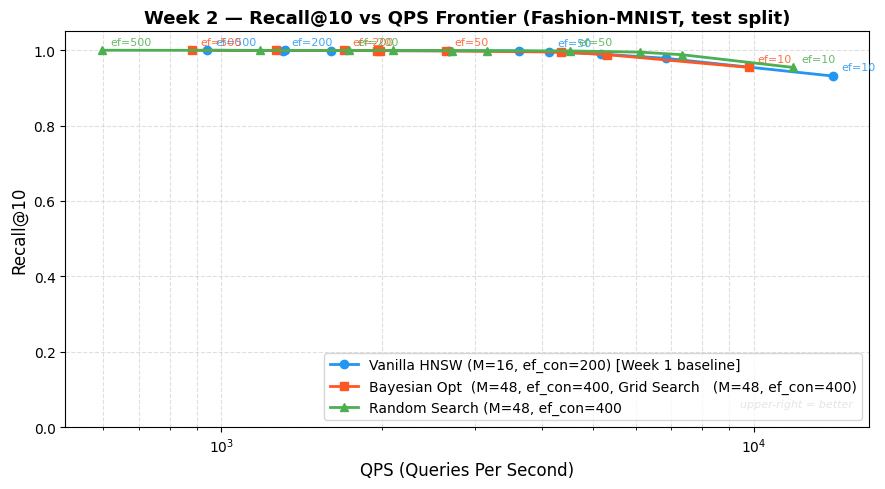

Plot saved to week2_recall_qps.png


In [16]:
plot_recall_qps(
    results_list=[
        vanilla_test_results,
        bayes_test_results,
        grid_test_results,
        random_test_results,
    ],
    labels=[
        f'Vanilla HNSW (M={M_DEFAULT}, ef_con={EF_CON_DEFAULT}) [Week 1 baseline]',
        f'Bayesian Opt  (M={bayes_best_M}, ef_con={bayes_best_ef_con}, '
        f'Grid Search   (M={best_grid["M"]}, ef_con={best_grid["ef_con"]})',
        f'Random Search (M={best_random["M"]}, ef_con={best_random["ef_con"]}'
    ],
    title='Week 2 — Recall@10 vs QPS Frontier (Fashion-MNIST, test split)',
    filename='week2_recall_qps.png'
)

## Section 11 — Summary

We report results at `ef_search=50` (a representative mid-range operating point)
and at `ef_search=500` (maximum recall) for each method.

In [24]:
def get_result_at_ef(results, ef):
    """Return the result dict for a specific ef_search value."""
    for r in results:
        if r['ef_search'] == ef:
            return r
    return None


def frontier_auc(results):
    """Area under the Recall-QPS curve (log-QPS axis), normalised to [0,1]."""
    qps_vals = np.array([r['qps'] for r in results])
    rec_vals = np.array([r['recall'] for r in results])
    log_qps  = np.log10(qps_vals)
    # Sort by ascending QPS
    order    = np.argsort(log_qps)
    log_qps, rec_vals = log_qps[order], rec_vals[order]
    # Trapezoidal AUC normalised by log-QPS range
    auc = np.trapezoid(rec_vals, log_qps) / (log_qps[-1] - log_qps[0])
    return auc


methods = [
    ('Vanilla (Week 1)',  M_DEFAULT,      EF_CON_DEFAULT,       'N/A',             vanilla_test_results),
    ('Bayesian Opt',      bayes_best_M,   bayes_best_ef_con,    bayes_build_time,  bayes_test_results),
    ('Grid Search',       best_grid['M'], best_grid['ef_con'],  grid_build_time,   grid_test_results),
    ('Random Search',     best_random['M'], best_random['ef_con'], random_build_time, random_test_results),
]

EF_REPORT = [50, 500]  # operating points to show

print("=" * 105)
print("WEEK 2 RESULTS SUMMARY  (held-out test set, Fashion-MNIST)")
print("=" * 105)
print(f"{'Method':<20} {'M':>4} {'ef_con':>6} {'Build(s)':>9}", end='')
for ef in EF_REPORT:
    print(f"  R@10(ef={ef:3d})  QPS(ef={ef:3d})", end='')
print(f"  {'AUC':>6}")
print("-" * 105)

for name, M, ef_con, bt, res in methods:
    auc   = frontier_auc(res)
    bt_str = f"{bt:.1f}" if isinstance(bt, float) else str(bt)
    print(f"{name:<20} {M:>4} {ef_con:>6} {bt_str:>9}", end='')
    for ef in EF_REPORT:
        r = get_result_at_ef(res, ef)
        if r:
            print(f"  {r['recall']:>12.4f}  {r['qps']:>12.1f}", end='')
        else:
            print(f"  {'N/A':>12}  {'N/A':>12}", end='')
    print(f"  {auc:>6.4f}")

print("=" * 105)
print()
print("Notes:")
print("  AUC = area under Recall-QPS curve (log-QPS axis), higher = better")
print()

best_name = max(methods, key=lambda x: frontier_auc(x[4]))[0]
print(f"Winner by AUC: {best_name}")
print()
print("This curve is carried forward to Week 3 as the optimised parameter baseline.")

WEEK 2 RESULTS SUMMARY  (held-out test set, Fashion-MNIST)
Method                  M ef_con  Build(s)  R@10(ef= 50)  QPS(ef= 50)  R@10(ef=500)  QPS(ef=500)     AUC
---------------------------------------------------------------------------------------------------------
Vanilla (Week 1)       16    200       N/A        0.9958        4131.8        0.9998         940.3  0.9850
Bayesian Opt           48    400      63.4        0.9980        2639.2        0.9998         882.5  0.9908
Grid Search            48    400      60.2        0.9980        4513.2        0.9998         596.3  0.9939
Random Search          48    400      60.3        0.9980        4581.4        0.9998         715.3  0.9947

Notes:
  AUC = area under Recall-QPS curve (log-QPS axis), higher = better

Winner by AUC: Random Search

This curve is carried forward to Week 3 as the optimised parameter baseline.


In [25]:
np.save('bayes_best_params.npy',  np.array({'M': bayes_best_M, 'ef_con': bayes_best_ef_con}, dtype=object))
np.save('bayes_results.npy',      np.array(bayes_test_results,  dtype=object))
np.save('grid_results.npy',       np.array(grid_test_results,   dtype=object))
np.save('random_results.npy',     np.array(random_test_results, dtype=object))
np.save('best_grid_params.npy',   np.array({'M': best_grid['M'],     'ef_con': best_grid['ef_con']},   dtype=object))
np.save('best_random_params.npy', np.array({'M': best_random['M'],   'ef_con': best_random['ef_con']}, dtype=object))
print("All Week 2 outputs saved. Download these to your Drive.")

All Week 2 outputs saved. Download these to your Drive.
